# Harbour & Home Direct: Dispatch Delays and Returns Review

1. #### Objective:
Analyse recent order and return activity for a UK e-commerce homewares retailer.
The goal is to identify:
- top-performing sales channels and product categories,
- areas with frequent dispatch delays,
- products/categories with high refund values,
- whether returns are linked to delayed orders,
- actions the Operations Performance Manager should prioritise.


## Analyze order performance, dispatch delays, and return patterns for Jan–Feb 2026, and provide recommendations to improve operations.

2. #### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

3. #### Load the data

In [2]:
base_path = r"C:\Users\jumma\python assignment next leap\harbour_home_dispatch_returns_assignment_full_pack\harbour_home_dispatch_returns_assignment\student\data"

orders = pd.read_csv(base_path + r"\order_lines.csv")
customers = pd.read_csv(base_path + r"\customers_lookup.csv")
products = pd.read_csv(base_path + r"\products_lookup.csv")
returns = pd.read_csv(base_path + r"\returns.csv")
data_dict = pd.read_csv(base_path + r"\data_dictionary.csv")

4. #### Initial Inspection

In [3]:
print("Orders shape:", orders.shape)
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Returns shape:", returns.shape)
print("Data dictionary shape:", data_dict.shape)

Orders shape: (33, 11)
Customers shape: (12, 5)
Products shape: (9, 5)
Returns shape: (11, 5)
Data dictionary shape: (26, 6)


In [19]:
orders.info()
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_line_id           33 non-null     object 
 1   order_id                33 non-null     object 
 2   order_date              33 non-null     object 
 3   customer_id             33 non-null     object 
 4   product_code            33 non-null     object 
 5   sales_channel           32 non-null     object 
 6   quantity                33 non-null     int64  
 7   unit_price_gbp          33 non-null     float64
 8   dispatch_status         33 non-null     object 
 9   dispatch_days           32 non-null     float64
 10  promised_dispatch_days  33 non-null     int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 3.0+ KB


order_line_id             0
order_id                  0
order_date                0
customer_id               0
product_code              0
sales_channel             1
quantity                  0
unit_price_gbp            0
dispatch_status           0
dispatch_days             1
promised_dispatch_days    0
dtype: int64

In [20]:
orders.head()

,order_line_id,order_id,order_date,customer_id,product_code,sales_channel,quantity,unit_price_gbp,dispatch_status,dispatch_days,promised_dispatch_days
0,OL1001,O5001,2026-01-03,C001,P100,Web,1,39.99,Dispatched,2.0,2
1,OL1002,O5001,2026/01/03,C001,P102,Web,2,14.50,Dispatched,2.0,2
2,OL1003,O5002,03-01-2026,C002,P101,App,1,24.99,Late,4.0,2
3,OL1004,O5003,2026-01-05,C003,P104,web,1,18.00,Dispatched,1.0,2
4,OL1005,O5004,2026-01-06,C004,P105,MarketPlace,1,64.99,Late,5.0,2


In [5]:
orders[orders["dispatch_days"].isna()]

,order_line_id,order_id,order_date,customer_id,product_code,sales_channel,quantity,unit_price_gbp,dispatch_status,dispatch_days,promised_dispatch_days
7,OL1008,O5007,2026-01-09,C007,P103,App,1,34.99,Cancelled,NaN,2


In [6]:
orders[orders["dispatch_days"].isna()][["order_id", "dispatch_status"]]


,order_id,dispatch_status
7,O5007,Cancelled


#### Data Quality Insight

The missing value in dispatch_days corresponds to an order with dispatch_status = 'cancelled'.

This is expected behaviour, as cancelled orders are not dispatched and therefore do not have a dispatch duration.

This confirms that the missing value is not a data quality issue but a valid business condition.


In [21]:
customers.info()
customers.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     12 non-null     object
 1   customer_name   12 non-null     object
 2   region          12 non-null     object
 3   customer_type   12 non-null     object
 4   signup_channel  12 non-null     object
dtypes: object(5)
memory usage: 612.0+ bytes


customer_id       0
customer_name     0
region            0
customer_type     0
signup_channel    0
dtype: int64

In [22]:
customers.head()

,customer_id,customer_name,region,customer_type,signup_channel
0,C001,Emma Lewis,london,Repeat,Email
1,C002,Daniel Shah,South east,New,Paid Search
2,C003,Priya Nair,Midlands,Repeat,Organic
3,C004,Oliver Evans,North west,VIP,Referral
4,C005,Hannah Jones,South-East,Repeat,Email


In [8]:
returns.info()
returns.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   return_id          11 non-null     object 
 1   order_line_id      11 non-null     object 
 2   return_date        11 non-null     object 
 3   return_reason      11 non-null     object 
 4   refund_amount_gbp  11 non-null     float64
dtypes: float64(1), object(4)
memory usage: 572.0+ bytes


return_id            0
order_line_id        0
return_date          0
return_reason        0
refund_amount_gbp    0
dtype: int64

In [18]:
returns.head()

,return_id,order_line_id,return_date,return_reason,refund_amount_gbp
0,R9001,OL1003,2026-01-12,Late Delivery,24.99
1,R9002,OL1005,2026/01/16,Damaged,64.99
2,R9003,OL1009,15-01-2026,late delivery,24.99
3,R9004,OL1013,2026-01-24,Damaged,64.99
4,R9005,OL1015,2026-01-28,Changed Mind,59.98


In [17]:
data_dict.info()
data_dict.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file_name      26 non-null     object
 1   column_name    26 non-null     object
 2   description    26 non-null     object
 3   data_type      26 non-null     object
 4   example_value  26 non-null     object
 5   notes          26 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


file_name        0
column_name      0
description      0
data_type        0
example_value    0
notes            0
dtype: int64

In [15]:
data_dict.head()

,file_name,column_name,description,data_type,example_value,notes
0,order_lines.csv,order_line_id,Unique identifier for each order line,text,OL1001,Primary row identifier in main fact table
1,order_lines.csv,order_id,Order identifier that may repeat across multip...,text,O5001,One order can contain multiple lines
2,order_lines.csv,order_date,Date order was placed,text date,2026-01-03,Contains inconsistent formats that should be s...
3,order_lines.csv,customer_id,Customer identifier,text,C001,Links to customers_lookup.csv and may need sta...
4,order_lines.csv,product_code,Product identifier,text,P100,Links to products_lookup.csv and may need stan...


In [10]:
products.info()
products.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_code   9 non-null      object
 1   product_name   9 non-null      object
 2   category       9 non-null      object
 3   subcategory    8 non-null      object
 4   supplier_name  9 non-null      object
dtypes: object(5)
memory usage: 492.0+ bytes


product_code     0
product_name     0
category         0
subcategory      1
supplier_name    0
dtype: int64

In [23]:
products.head()

,product_code,product_name,category,subcategory,supplier_name
0,P100,Bamboo Laundry Basket,Home Storage,Laundry,Oak & Pine Supplies
1,P101,Underbed Storage Set,home storage,Storage Boxes,ClearSpace Imports
2,P102,Velvet Cushion Cover,Soft Furnishing,Cushions,North Loom Textiles
3,P103,Blackout Curtain Panel,Soft Furnishings,Window,North Loom Textiles
4,P104,Desk Organiser Set,Home Office,Desk Storage,WorkWell Goods


In [11]:
products[products["subcategory"].isna()]

,product_code,product_name,category,subcategory,supplier_name
8,P108,Bath Towel Pair,Home Essentials,NaN,Cotton Lane


#### Data Quality Observation

One product (Bath Towel Pair) has a missing subcategory value.

Unlike dispatch_days, this is not due to business logic but indicates incomplete product classification.

Subcategory is an important attribute for product hierarchy and reporting,
and missing values may reduce the accuracy of category-level analysis.


In [12]:
products["subcategory"] = products["subcategory"].fillna("not specified")

5. #### Clean and Standardise the Data

##### Standardise column names

In [24]:
orders.columns = orders.columns.str.strip().str.lower()
customers.columns = customers.columns.str.strip().str.lower()
products.columns = products.columns.str.strip().str.lower()
returns.columns = returns.columns.str.strip().str.lower()

##### Standardise text fields

In [25]:
def clean_text(series):
    return series.astype(str).str.strip().str.lower()

In [26]:
# clean for each dataframe 
for df in [orders, customers, products, returns]:
    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        df[col] = clean_text(df[col])

##### Replace blank strings with missing values

In [27]:
for df in [orders, customers, products, returns]:
    df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

##### Convert numeric columns

In [28]:
numeric_cols_orders = ["quantity", "unit_price_gbp", "dispatch_days", "promised_dispatch_days"]
for col in numeric_cols_orders:
    if col in orders.columns:
        orders[col] = pd.to_numeric(orders[col], errors="coerce")

if "refund_amount_gbp" in returns.columns:
    returns["refund_amount_gbp"] = pd.to_numeric(returns["refund_amount_gbp"], errors="coerce")

##### Convert date columns

In [29]:
date_cols_orders = ["order_date"]
date_cols_returns = ["return_date"]

for col in date_cols_orders:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors="coerce", dayfirst=True)

for col in date_cols_returns:
    if col in returns.columns:
        returns[col] = pd.to_datetime(returns[col], errors="coerce", dayfirst=True)

##### Check duplicate rows in order file

In [30]:
orders.duplicated().sum()

np.int64(1)

In [31]:
orders[orders.duplicated()]

,order_line_id,order_id,order_date,customer_id,product_code,sales_channel,quantity,unit_price_gbp,dispatch_status,dispatch_days,promised_dispatch_days
32,ol1018,o5017,NaT,c005,p101,web,1,24.99,late,5.0,2


In [32]:
orders = orders.drop_duplicates()
print("Orders shape after removing duplicates:", orders.shape)

Orders shape after removing duplicates: (32, 11)


##### Check key data quality issues

In [33]:
print("Unique sales_channel values:")
print(orders["sales_channel"].value_counts(dropna=False))

Unique sales_channel values:
sales_channel
web            15
app            10
marketplace     6
nan             1
Name: count, dtype: int64


In [34]:
print("Unique region values:")
print(customers["region"].value_counts(dropna=False))

Unique region values:
region
london                  2
south east              2
midlands                2
north west              2
south-east              1
scotland                1
wales                   1
yorkshire and humber    1
Name: count, dtype: int64


In [35]:
print("Unique category values:")
print(products["category"].value_counts(dropna=False))

Unique category values:
category
home storage        3
soft furnishing     1
soft furnishings    1
home office         1
lighting            1
kitchen             1
home essentials     1
Name: count, dtype: int64


In [36]:
print("Unique subcategory values:")
print(products["subcategory"].value_counts(dropna=False))

Unique subcategory values:
subcategory
laundry          1
storage boxes    1
cushions         1
window           1
desk storage     1
lamps            1
hallway          1
food storage     1
not specified    1
Name: count, dtype: int64


6. ####  Create Calculated Fields

##### Line revenue

In [37]:
orders["line_revenue"] = orders["quantity"] * orders["unit_price_gbp"]

##### Late dispatch flag

In [38]:
orders["late_dispatch_flag"] = np.where(
    orders["dispatch_days"] > orders["promised_dispatch_days"], 1, 0
)

Quick inspection of new fields

In [39]:
orders[["order_line_id", "quantity", "unit_price_gbp", "line_revenue", 
        "dispatch_days", "promised_dispatch_days", "late_dispatch_flag"]].head()

,order_line_id,quantity,unit_price_gbp,line_revenue,dispatch_days,promised_dispatch_days,late_dispatch_flag
0,ol1001,1,39.99,39.99,2.0,2,0
1,ol1002,2,14.50,29.00,2.0,2,0
2,ol1003,1,24.99,24.99,4.0,2,1
3,ol1004,1,18.00,18.00,1.0,2,0
4,ol1005,1,64.99,64.99,5.0,2,1


#### 7. Merge the Data

In [40]:
print("Orders rows before merge:", len(orders))

Orders rows before merge: 32


In [41]:
merged = orders.merge(customers, on="customer_id", how="left")
print("Rows after customer merge:", len(merged))

Rows after customer merge: 32


In [42]:
merged = merged.merge(products, on="product_code", how="left")
print("Rows after product merge:", len(merged))

Rows after product merge: 32


In [43]:
merged = merged.merge(returns, on="order_line_id", how="left")
print("Rows after returns merge:", len(merged))

Rows after returns merge: 32


##### Validate row counts

In [44]:
print("Original order rows:", len(orders))
print("Final merged rows:", len(merged))

Original order rows: 32
Final merged rows: 32


####  8. Missing Values after merge

In [45]:
merged.isnull().sum().sort_values(ascending=False)

return_date               30
refund_amount_gbp         21
return_reason             21
return_id                 21
order_date                15
dispatch_days              1
region                     0
supplier_name              0
subcategory                0
category                   0
product_name               0
signup_channel             0
customer_type              0
order_line_id              0
customer_name              0
order_id                   0
line_revenue               0
promised_dispatch_days     0
dispatch_status            0
unit_price_gbp             0
quantity                   0
sales_channel              0
product_code               0
customer_id                0
late_dispatch_flag         0
dtype: int64

#### 9.Create Return Flag

In [47]:
merged["return_flag"] = np.where(merged["refund_amount_gbp"].notna(), 1, 0)

#### 10. Exploratory Analysis

##### 1.Which sales channels generated the highest revenue?

In [48]:
channel_revenue = (
    merged.groupby("sales_channel", dropna=False)["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

channel_revenue

,sales_channel,line_revenue
0,web,625.41
1,app,406.91
2,marketplace,293.94
3,nan,24.99


##### 2.Which product categories generated the highest revenue?

In [50]:
category_revenue = (
    merged.groupby("category", dropna=False)["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,line_revenue
0,home storage,529.83
1,lighting,259.96
2,soft furnishings,139.96
3,home essentials,136.50
4,home office,126.00
5,soft furnishing,87.00
6,kitchen,72.00


##### 3.  Where are late dispatches appearing most often?

late by region

In [56]:
late_by_region = (
    merged.groupby("region", dropna=False)["late_dispatch_flag"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

late_by_region

,region,late_dispatch_flag
0,london,4
1,south east,3
2,midlands,2
3,north west,2
4,south-east,1
5,scotland,0
6,wales,0
7,yorkshire and humber,0


late by channel 

In [57]:
late_by_channel = (
    merged.groupby("sales_channel", dropna=False)["late_dispatch_flag"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

late_by_channel

,sales_channel,late_dispatch_flag
0,app,5
1,marketplace,4
2,web,2
3,nan,1


late by category

In [58]:
late_by_category = (
    merged.groupby("category", dropna=False)["late_dispatch_flag"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

late_by_category

,category,late_dispatch_flag
0,home storage,8
1,lighting,4
2,home essentials,0
3,home office,0
4,kitchen,0
5,soft furnishing,0
6,soft furnishings,0


##### 4. Which products or categories generated the highest refund values?

refund by category 

In [59]:
category_refunds = (
    merged.groupby("category", dropna=False)["refund_amount_gbp"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_refunds

,category,refund_amount_gbp
0,home storage,269.90
1,lighting,259.96
2,home essentials,0.00
3,home office,0.00
4,kitchen,0.00
5,soft furnishing,0.00
6,soft furnishings,0.00


refund by products

In [63]:
product_refunds = (
    merged.groupby("product_code", dropna=False)["refund_amount_gbp"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_refunds

,product_code,refund_amount_gbp
0,p105,259.96
1,p101,149.94
2,p106,119.96
3,p100,0.00
4,p102,0.00
5,p103,0.00
6,p104,0.00
7,p107,0.00
8,p108,0.00


#### 5. Are returns concentrated in delayed orders?

In [64]:
returns_by_delay = (
    merged.groupby("late_dispatch_flag")["return_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

returns_by_delay.columns = ["late_dispatch_flag", "total_order_lines", "returned_order_lines", "return_rate"]
returns_by_delay

,late_dispatch_flag,total_order_lines,returned_order_lines,return_rate
0,0,20,0,0.000000
1,1,12,11,0.916667


In [65]:
returns_by_delay["return_rate_pct"] = returns_by_delay["return_rate"] * 100
returns_by_delay

,late_dispatch_flag,total_order_lines,returned_order_lines,return_rate,return_rate_pct
0,0,20,0,0.000000,0.000000
1,1,12,11,0.916667,91.666667


#### 11. Visualisation 

##### Revenue by sales channel

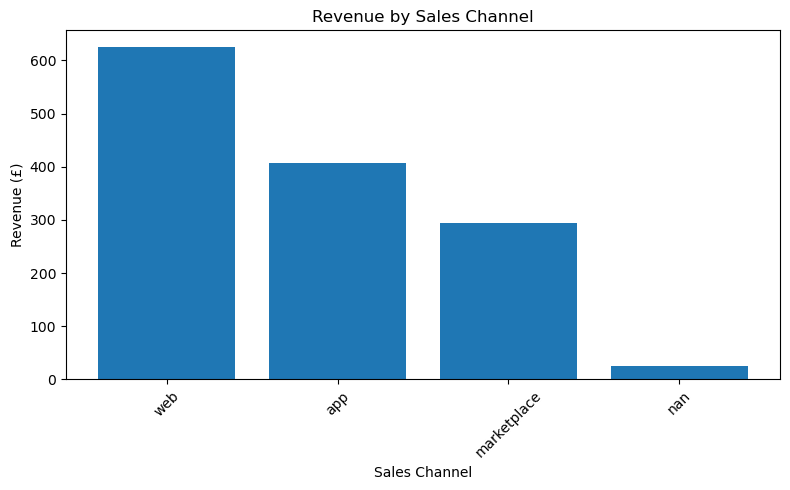

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(channel_revenue["sales_channel"].astype(str), channel_revenue["line_revenue"])
plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Revenue by category

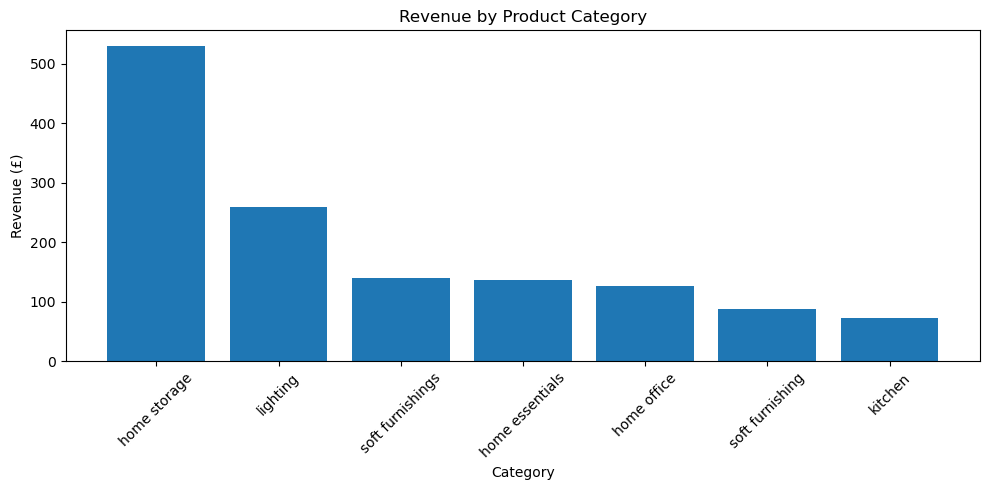

In [67]:
plt.figure(figsize=(10, 5))
plt.bar(category_revenue["category"].astype(str), category_revenue["line_revenue"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Late dispatches by region

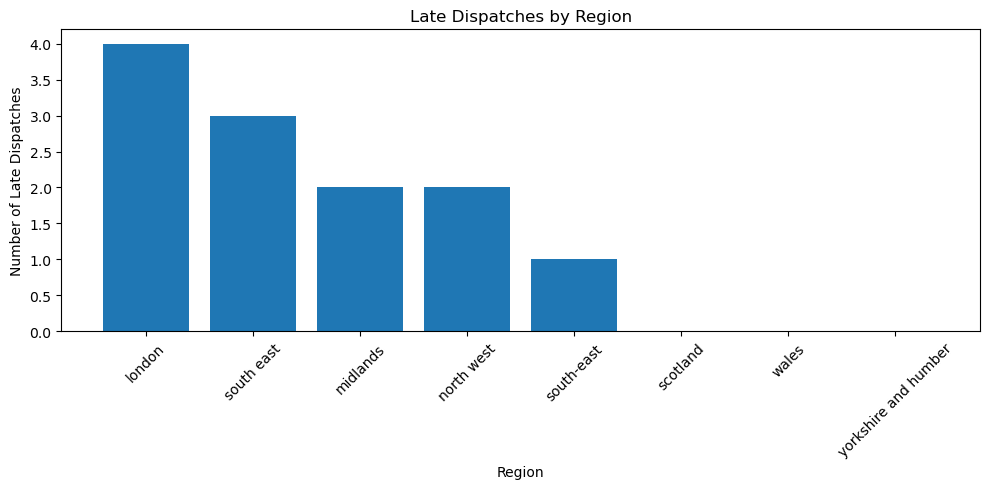

In [68]:
plt.figure(figsize=(10, 5))
plt.bar(late_by_region["region"].astype(str), late_by_region["late_dispatch_flag"])
plt.title("Late Dispatches by Region")
plt.xlabel("Region")
plt.ylabel("Number of Late Dispatches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Refund values by category

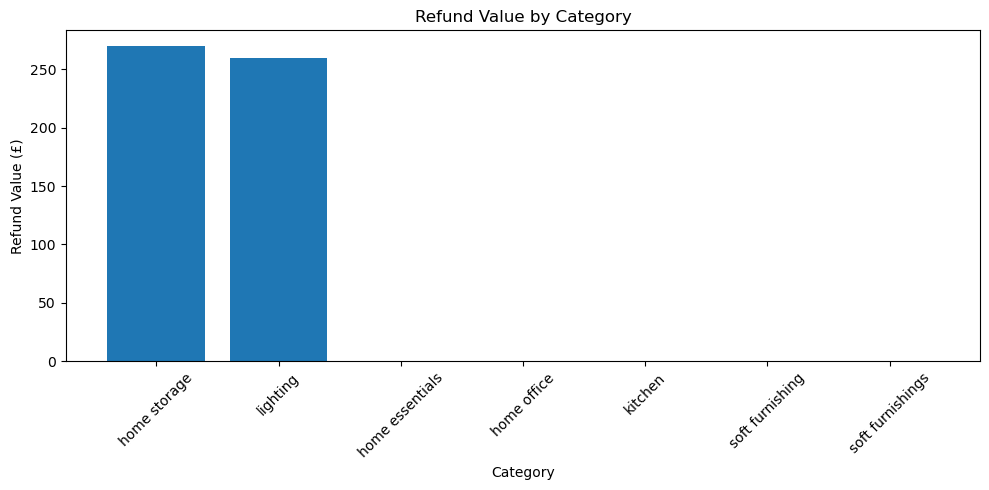

In [69]:
plt.figure(figsize=(10, 5))
plt.bar(category_refunds["category"].astype(str), category_refunds["refund_amount_gbp"])
plt.title("Refund Value by Category")
plt.xlabel("Category")
plt.ylabel("Refund Value (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Return rate for delayed vs non-delayed orders

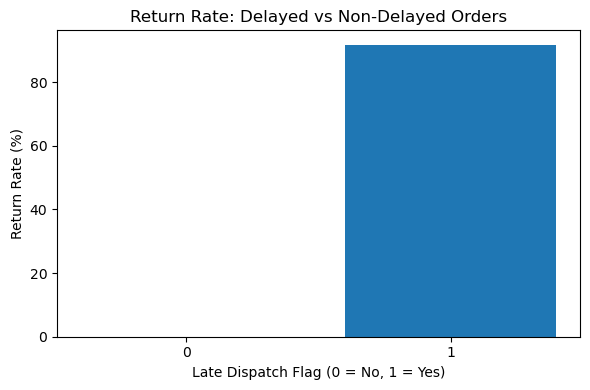

In [70]:
plt.figure(figsize=(6, 4))
plt.bar(returns_by_delay["late_dispatch_flag"].astype(str), returns_by_delay["return_rate_pct"])
plt.title("Return Rate: Delayed vs Non-Delayed Orders")
plt.xlabel("Late Dispatch Flag (0 = No, 1 = Yes)")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.show()

#### 12. Key findings

In [71]:
print("Revenue by sales channel:")
print(channel_revenue)

print("\nRevenue by category:")
print(category_revenue)

print("\nLate dispatches by region:")
print(late_by_region)

print("\nRefunds by category:")
print(category_refunds)

print("\nReturns by delay status:")
print(returns_by_delay)

Revenue by sales channel:
  sales_channel  line_revenue
0           web        625.41
1           app        406.91
2   marketplace        293.94
3           nan         24.99

Revenue by category:
           category  line_revenue
0      home storage        529.83
1          lighting        259.96
2  soft furnishings        139.96
3   home essentials        136.50
4       home office        126.00
5   soft furnishing         87.00
6           kitchen         72.00

Late dispatches by region:
                 region  late_dispatch_flag
0                london                   4
1            south east                   3
2              midlands                   2
3            north west                   2
4            south-east                   1
5              scotland                   0
6                 wales                   0
7  yorkshire and humber                   0

Refunds by category:
           category  refund_amount_gbp
0      home storage             269.90
1     

#### 13. Written Business Commentary

##### 13.1 Sales channel performance

In [72]:
top_channel = channel_revenue.iloc[0]["sales_channel"]
top_channel_revenue = channel_revenue.iloc[0]["line_revenue"]

print(f"The highest revenue came from the {top_channel} channel, generating £{top_channel_revenue:.2f}.")
print("This suggests that this channel is the strongest revenue driver during the analysis period.")

The highest revenue came from the web channel, generating £625.41.
This suggests that this channel is the strongest revenue driver during the analysis period.


The web channel generated the highest revenue, followed by app and marketplace.
This suggests that digital direct channels are the strongest commercial drivers for the business.
There is also one missing sales_channel value, which indicates a data quality issue that should be addressed.


##### 13.2 Product category performance

In [74]:
top_category = category_revenue.iloc[0]["category"]
top_category_revenue = category_revenue.iloc[0]["line_revenue"]

print(f"The highest revenue category was {top_category}, generating £{top_category_revenue:.2f}.")

The highest revenue category was home storage, generating £529.83.


Home storage generated the highest revenue, followed by lighting.
This indicates strong demand in these categories and suggests they are important areas for inventory planning and commercial focus.


##### 13.3 Late dispatch trends

In [75]:
top_delay_region = late_by_region.iloc[0]["region"]
top_delay_count = late_by_region.iloc[0]["late_dispatch_flag"]

print(f"The region with the highest number of late dispatches was {top_delay_region}, with {int(top_delay_count)} delays.")

The region with the highest number of late dispatches was london, with 4 delays.


Late dispatches appeared most often in London and the South East.
This may reflect higher order volumes, warehouse pressure, or courier delays in these areas.
Reducing delays in these regions could improve customer satisfaction and reduce operational issues.

##### 13.4 Refund concentration

In [76]:
top_refund_category = category_refunds.iloc[0]["category"]
top_refund_value = category_refunds.iloc[0]["refund_amount_gbp"]

print(f"The category with the highest refund value was {top_refund_category}, at £{top_refund_value:.2f}.")

The category with the highest refund value was home storage, at £269.90.


The highest refund values came from home storage and lighting.
These categories are also among the strongest revenue generators, which makes them commercially important but operationally risky.
Possible reasons include product quality issues, fragile items, packaging weaknesses, or inaccurate product descriptions.


##### 13.5 Returns vs delays

In [77]:
returns_by_delay

,late_dispatch_flag,total_order_lines,returned_order_lines,return_rate,return_rate_pct
0,0,20,0,0.000000,0.000000
1,1,12,11,0.916667,91.666667


Returns are heavily concentrated in delayed orders.
On-time orders had a return rate of 0%, while delayed orders had a return rate of approximately 91.7%.
This is the strongest finding in the analysis and suggests that late dispatch is a major driver of returns and customer dissatisfaction.

#### 14. Final Recommendations

Recommendations
---------------
1. Prioritise reducing dispatch delays
   Late orders are strongly associated with returns, so improving fulfilment performance should be the main operational priority.

2. Investigate high-refund categories
   Home storage and lighting should be reviewed for product quality, packaging, and listing accuracy.

3. Protect strong revenue channels
   The web and app channels are the main revenue contributors, so maintaining a strong customer experience in these channels is important.

4. Improve data quality controls
   Missing sales_channel values, inconsistent region naming, blank subcategories, and duplicate rows should be addressed through validation rules and standardised input processes.

5. Improve customer communication
   Better delivery updates and more accurate dispatch expectations may reduce dissatisfaction and return behaviour.

#### 15. Final Conclusion

Conclusion
----------
This analysis identified that web and app channels generate the majority of revenue, while home storage and lighting are the top-performing product categories.

However, these same categories also generate the highest refund values, suggesting that they require closer operational attention.

The most important finding is that returns are highly concentrated in delayed orders. Delayed order lines showed a very high return rate, while on-time order lines showed no returns. This indicates that dispatch performance is a major driver of customer dissatisfaction and refunds.

Overall, the Operations Performance Manager should prioritise dispatch improvement, investigate the highest refund categories, and strengthen data quality controls to support better reporting and decision-making.


##### Main output from this dataset